In [9]:
# Cell 1: Setup and Imports - Time Series
!pip install pandas numpy matplotlib seaborn statsmodels prophet scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time series specific
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   Prophet version: {Prophet.__version__ if hasattr(Prophet, '__version__') else 'installed'}")

✅ All imports loaded successfully!
   Prophet version: installed


In [6]:
# Cell 2: Generate Synthetic Time Series Data
print("="*70)
print("📈 GENERATING SYNTHETIC TIME SERIES DATA")
print("="*70)

np.random.seed(42)

# Generate date range (2 years of daily data)
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
n = len(dates)

# Components of time series
trend = np.linspace(100, 200, n)  # Upward trend
seasonal_yearly = 20 * np.sin(2 * np.pi * np.arange(n) / 365)  # Yearly seasonality
seasonal_weekly = 10 * np.sin(2 * np.pi * np.arange(n) / 7)  # Weekly seasonality

# Holiday effects (spikes)
holiday_effect = np.zeros(n)
holiday_indices = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]  # Approximate monthly
for idx in holiday_indices:
    if idx < n:
        holiday_effect[idx] += np.random.uniform(15, 30)

# Noise
noise = np.random.normal(0, 5, n)

# Combine components
values = trend + seasonal_yearly + seasonal_weekly + holiday_effect + noise
values = np.maximum(values, 10)  # No negative values

# Create DataFrame
df = pd.DataFrame({
    'ds': dates,
    'y': values.round(2),
    'trend': trend,
    'seasonal_yearly': seasonal_yearly,
    'seasonal_weekly': seasonal_weekly,
    'holiday_effect': holiday_effect
})

print(f"✅ Generated {len(df)} daily records")
print(f"   Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"   Value range: {df['y'].min():.2f} to {df['y'].max():.2f}")
print(f"   Mean value: {df['y'].mean():.2f}")

print("\n📊 Sample data:")
print(df.head(10))

📈 GENERATING SYNTHETIC TIME SERIES DATA
✅ Generated 731 daily records
   Date range: 2023-01-01 to 2024-12-31
   Value range: 83.09 to 218.08
   Mean value: 150.31

📊 Sample data:
          ds       y       trend  seasonal_yearly  seasonal_weekly  \
0 2023-01-01   97.65  100.000000         0.000000     0.000000e+00   
1 2023-01-02  111.01  100.136986         0.344267     7.818315e+00   
2 2023-01-03  108.39  100.273973         0.688432     9.749279e+00   
3 2023-01-04  103.45  100.410959         1.032393     4.338837e+00   
4 2023-01-05   98.79  100.547945         1.376049    -4.338837e+00   
5 2023-01-06   83.09  100.684932         1.719296    -9.749279e+00   
6 2023-01-07   86.44  100.821918         2.062034    -7.818315e+00   
7 2023-01-08  100.55  100.958904         2.404161    -2.449294e-15   
8 2023-01-09  106.60  101.095890         2.745575     7.818315e+00   
9 2023-01-10  115.64  101.232877         3.086176     9.749279e+00   

   holiday_effect  
0             0.0  
1        

📊 EXPLORATORY TIME SERIES VISUALIZATION


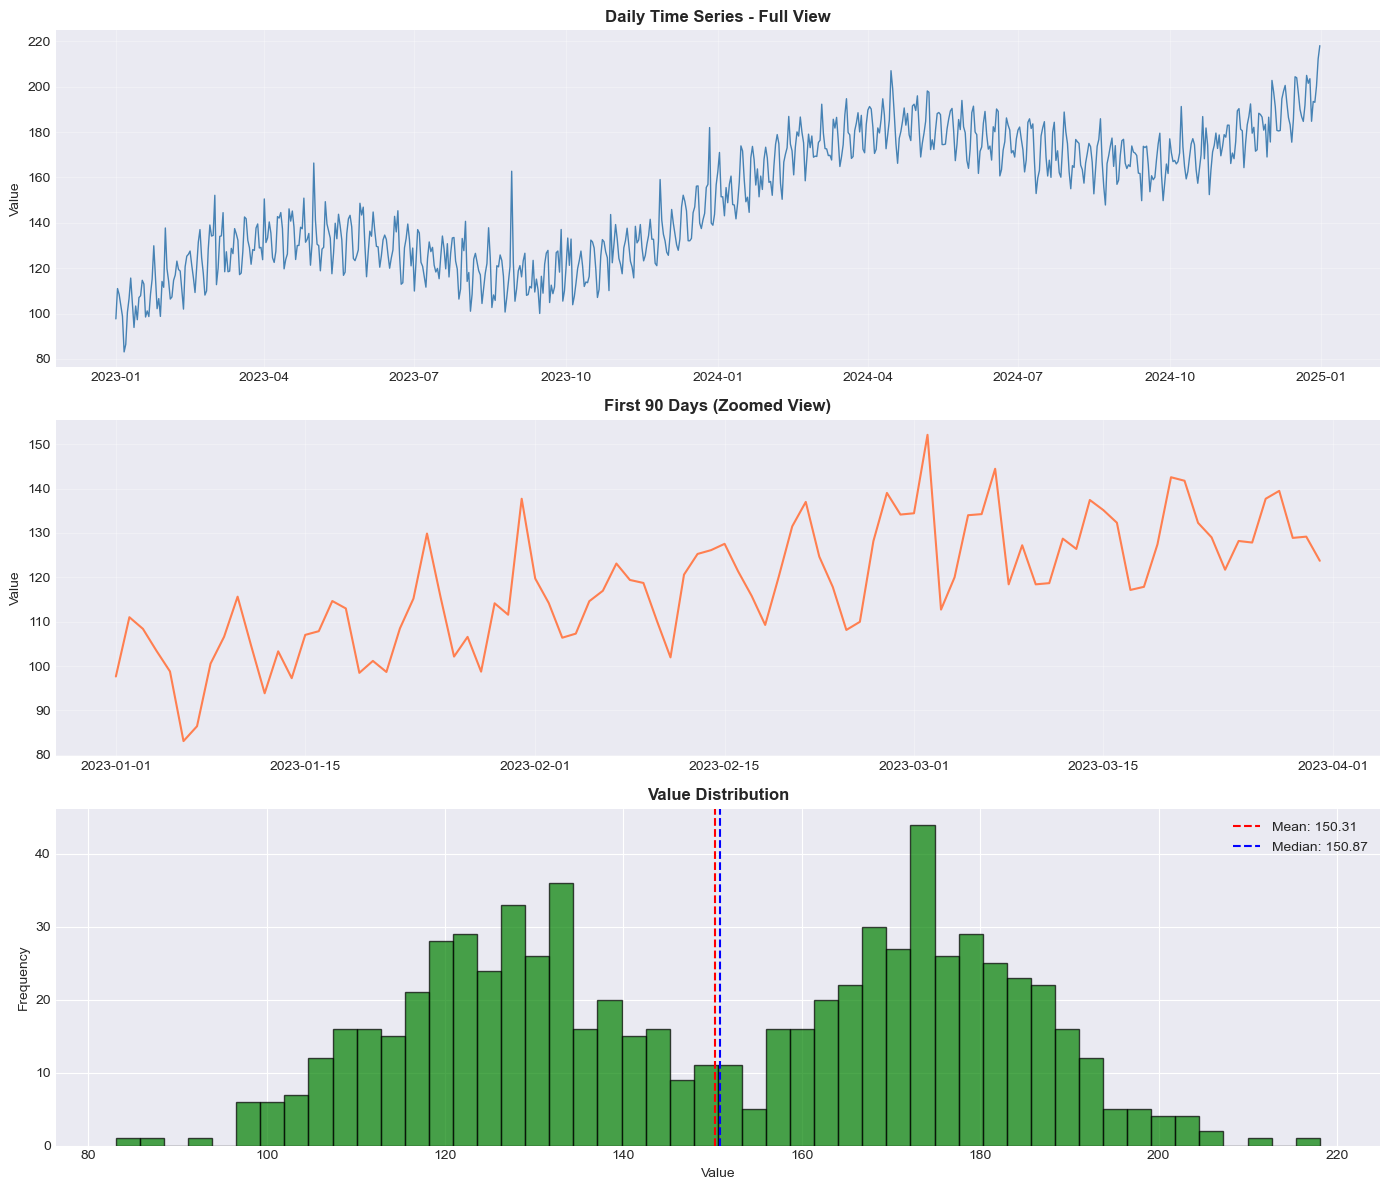

✅ Saved: time_series_overview.png


In [11]:
# Cell 3: Exploratory Time Series Visualization
print("="*70)
print("📊 EXPLORATORY TIME SERIES VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Full time series
ax1 = axes[0]
ax1.plot(df['ds'], df['y'], linewidth=1, color='steelblue')
ax1.set_title('Daily Time Series - Full View', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value')
ax1.grid(True, alpha=0.3)

# 2. First 90 days (zoom in)
ax2 = axes[1]
first_90 = df.head(90)
ax2.plot(first_90['ds'], first_90['y'], linewidth=1.5, color='coral')
ax2.set_title('First 90 Days (Zoomed View)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(True, alpha=0.3)

# 3. Distribution
ax3 = axes[2]
ax3.hist(df['y'], bins=50, color='green', edgecolor='black', alpha=0.7)
ax3.axvline(df['y'].mean(), color='red', linestyle='--', label=f'Mean: {df["y"].mean():.2f}')
ax3.axvline(df['y'].median(), color='blue', linestyle='--', label=f'Median: {df["y"].median():.2f}')
ax3.set_title('Value Distribution', fontsize=12, fontweight='bold')  # FIXED: fontweight not font-weight
ax3.set_xlabel('Value')
ax3.set_ylabel('Frequency')
ax3.legend()

plt.tight_layout()
plt.savefig('time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: time_series_overview.png")

🔍 TIME SERIES DECOMPOSITION


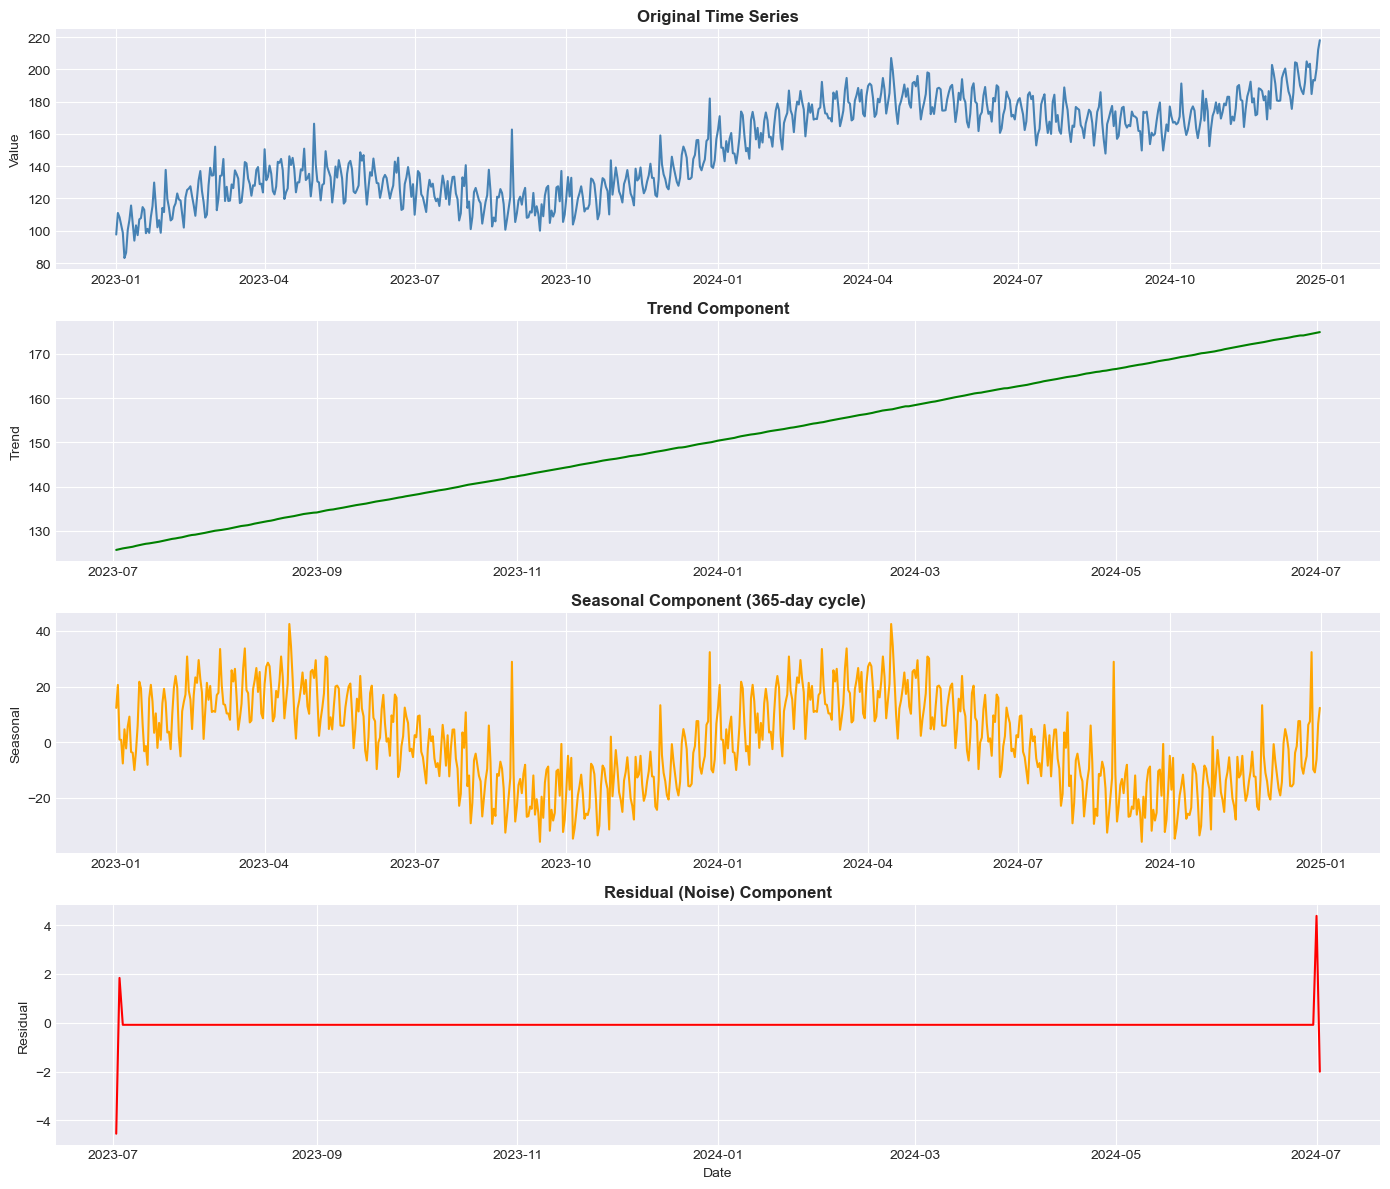

✅ Saved: time_series_decomposition.png

📊 Decomposition Insights:
   Trend direction: Downward
   Seasonal amplitude: 78.40
   Noise level (std): 0.36


In [12]:
# Cell 4: Time Series Decomposition
print("="*70)
print("🔍 TIME SERIES DECOMPOSITION")
print("="*70)

# Perform additive decomposition
decomposition = seasonal_decompose(df['y'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(df['ds'], df['y'], color='steelblue')
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value')

# Trend
axes[1].plot(df['ds'], decomposition.trend, color='green')
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Seasonal
axes[2].plot(df['ds'], decomposition.seasonal, color='orange')
axes[2].set_title('Seasonal Component (365-day cycle)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Residual
axes[3].plot(df['ds'], decomposition.resid, color='red')
axes[3].set_title('Residual (Noise) Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: time_series_decomposition.png")

print("\n📊 Decomposition Insights:")
print(f"   Trend direction: {'Upward' if decomposition.trend.iloc[-1] > decomposition.trend.iloc[0] else 'Downward'}")
print(f"   Seasonal amplitude: {decomposition.seasonal.max() - decomposition.seasonal.min():.2f}")
print(f"   Noise level (std): {decomposition.resid.std():.2f}")

📊 STATIONARITY TEST (ADF TEST)

TESTING ORIGINAL SERIES

Original Series
--------------------------------------------------
ADF Statistic: -0.331991
p-value: 0.920850
Critical Values:
   1%: -3.439594
   5%: -2.865619
   10%: -2.568942

❌ Series is NON-STATIONARY (fail to reject H0)

TESTING DIFFERENCED SERIES (1st order)

Differenced Series
--------------------------------------------------
ADF Statistic: -6.493146
p-value: 0.000000
Critical Values:
   1%: -3.439594
   5%: -2.865619
   10%: -2.568942

✅ Series is STATIONARY (reject H0)


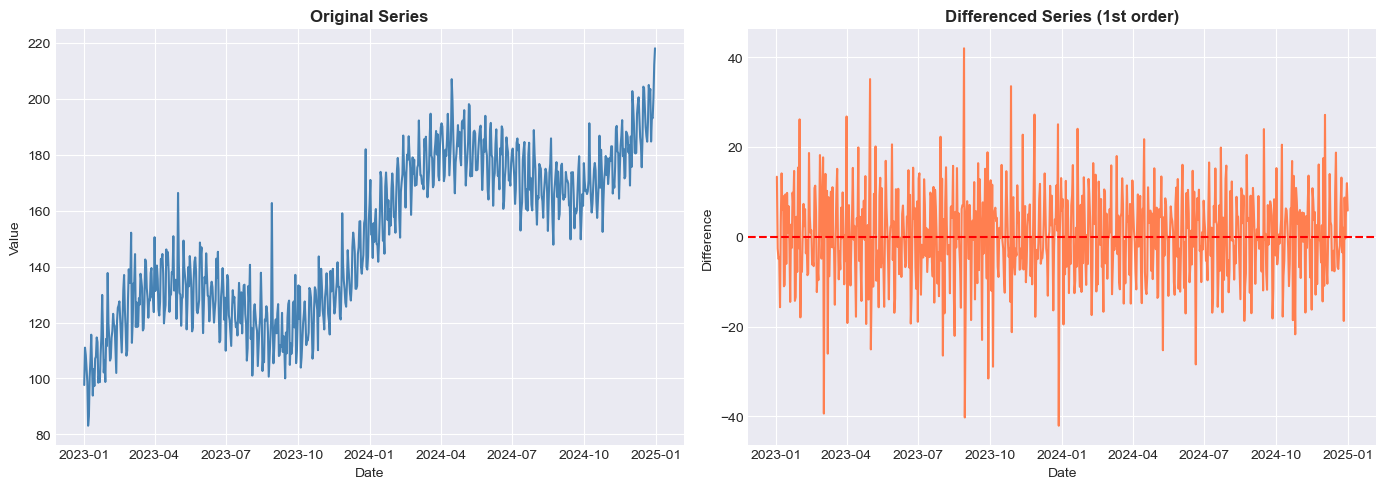

✅ Saved: stationarity_test.png


In [13]:
# Cell 5: Stationarity Test (Augmented Dickey-Fuller)
print("="*70)
print("📊 STATIONARITY TEST (ADF TEST)")
print("="*70)

def adf_test(series, title=''):
    """Perform Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"\n{title}")
    print("-"*50)
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.6f}')
    
    if result[1] <= 0.05:
        print("\n✅ Series is STATIONARY (reject H0)")
        return True
    else:
        print("\n❌ Series is NON-STATIONARY (fail to reject H0)")
        return False

# Test original series
print("\n" + "="*40)
print("TESTING ORIGINAL SERIES")
print("="*40)
is_stationary = adf_test(df['y'], "Original Series")

# If not stationary, apply differencing
if not is_stationary:
    df['y_diff'] = df['y'].diff()
    print("\n" + "="*40)
    print("TESTING DIFFERENCED SERIES (1st order)")
    print("="*40)
    adf_test(df['y_diff'], "Differenced Series")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['ds'], df['y'], color='steelblue')
axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Value')

axes[1].plot(df['ds'], df['y'].diff(), color='coral')
axes[1].set_title('Differenced Series (1st order)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Difference')
axes[1].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('stationarity_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stationarity_test.png")

📊 ACF & PACF ANALYSIS


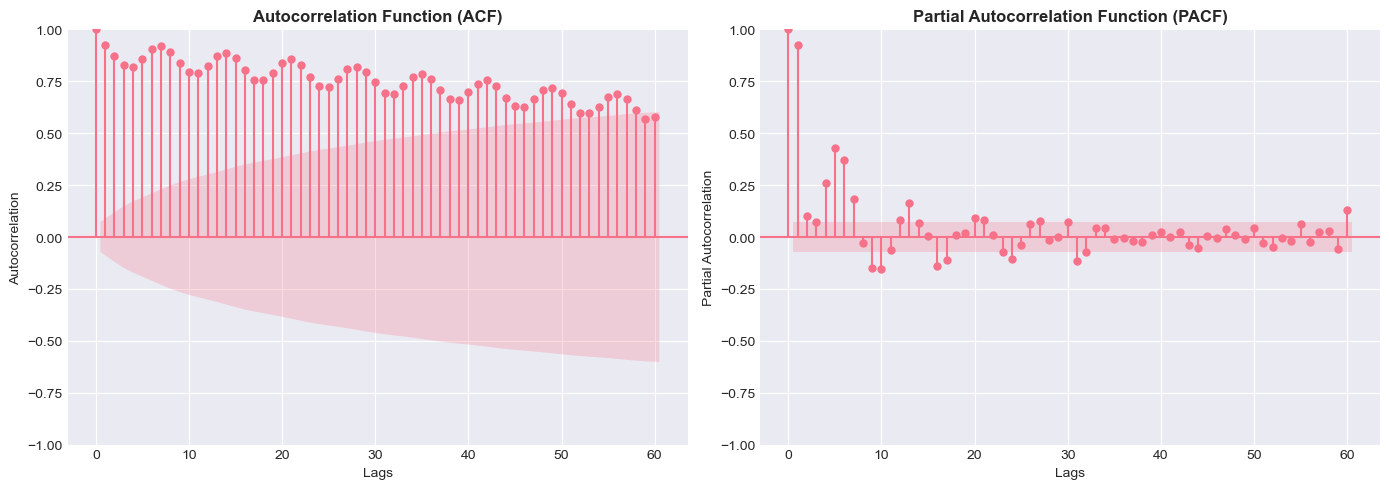

✅ Saved: acf_pacf_plots.png

📊 Interpretation:
   - Significant ACF lags: Indicates AR components
   - Significant PACF lags: Indicates MA components
   - Slow decay in ACF: Suggests non-stationarity


In [14]:
# Cell 6: ACF and PACF Plots
print("="*70)
print("📊 ACF & PACF ANALYSIS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
plot_acf(df['y'].dropna(), lags=60, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# PACF plot
plot_pacf(df['y'].dropna(), lags=60, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: acf_pacf_plots.png")

print("\n📊 Interpretation:")
print("   - Significant ACF lags: Indicates AR components")
print("   - Significant PACF lags: Indicates MA components")
print("   - Slow decay in ACF: Suggests non-stationarity")

📊 TRAIN-TEST SPLIT (Time Series)
✅ Training set: 671 days (2023-01-01 to 2024-11-01)
✅ Test set: 60 days (2024-11-02 to 2024-12-31)


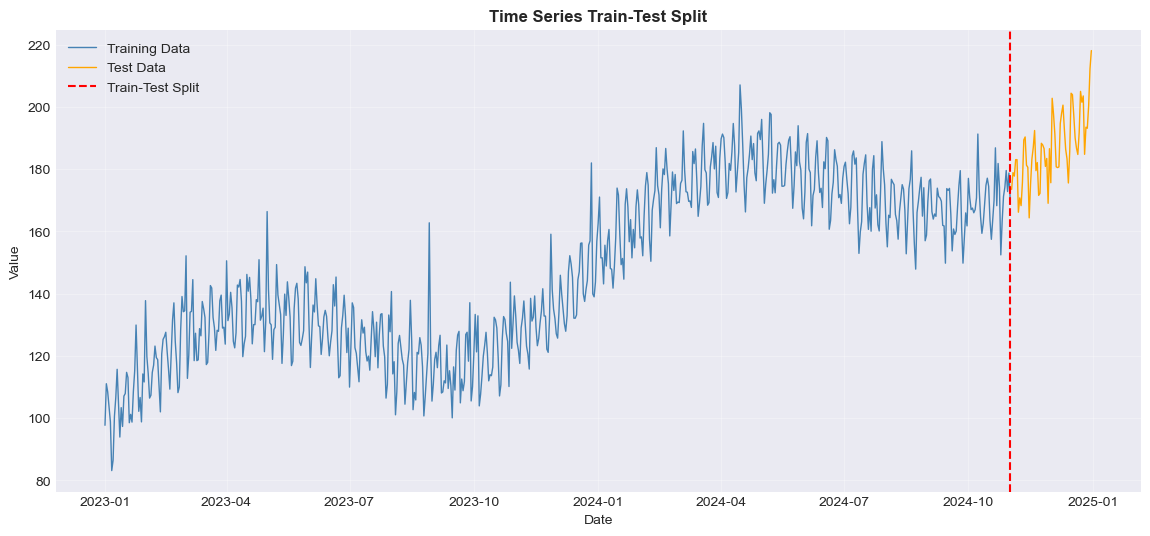

✅ Saved: train_test_split.png


In [15]:
# Cell 7: Train-Test Split for Time Series
print("="*70)
print("📊 TRAIN-TEST SPLIT (Time Series)")
print("="*70)

# Use last 60 days for testing
train_size = len(df) - 60
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

print(f"✅ Training set: {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"✅ Test set: {len(test)} days ({test['ds'].min().date()} to {test['ds'].max().date()})")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(train['ds'], train['y'], label='Training Data', color='steelblue', linewidth=1)
plt.plot(test['ds'], test['y'], label='Test Data', color='orange', linewidth=1)
plt.axvline(x=train['ds'].iloc[-1], color='red', linestyle='--', label='Train-Test Split')
plt.title('Time Series Train-Test Split', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: train_test_split.png")

In [16]:
# Cell 8: ARIMA Model
print("="*70)
print("📊 ARIMA MODEL")
print("="*70)

# Based on ACF/PACF, choose order (p,d,q)
# p = AR order (from PACF), d = differencing (1), q = MA order (from ACF)
p, d, q = 5, 1, 2

print(f"Model order: ARIMA({p},{d},{q})")

# Fit ARIMA model
arima_model = ARIMA(train['y'], order=(p, d, q))
arima_fitted = arima_model.fit()

print("\n📊 ARIMA Model Summary:")
print(arima_fitted.summary())

# Make predictions
arima_predictions = arima_fitted.forecast(steps=len(test))
arima_predictions = pd.Series(arima_predictions, index=test.index)

# Calculate metrics
arima_mae = mean_absolute_error(test['y'], arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_predictions))
arima_mape = mean_absolute_percentage_error(test['y'], arima_predictions)

print(f"\n📊 ARIMA Performance:")
print(f"   MAE: {arima_mae:.2f}")
print(f"   RMSE: {arima_rmse:.2f}")
print(f"   MAPE: {arima_mape:.2%}")

📊 ARIMA MODEL
Model order: ARIMA(5,1,2)

📊 ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  671
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -2232.424
Date:                Mon, 18 May 2026   AIC                           4480.847
Time:                        23:50:55   BIC                           4516.905
Sample:                             0   HQIC                          4494.814
                                - 671                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3999      0.043      9.391      0.000       0.316       0.483
ar.L2         -0.5318      0.037    -14.207      0.000      -0.605 

In [18]:
# Cell 9: Exponential Smoothing (Holt-Winters)
print("="*70)
print("📊 EXPONENTIAL SMOOTHING (HOLT-WINTERS)")
print("="*70)

# Use weekly seasonality (7 days) instead of yearly (365)
# since we don't have 2 full years for yearly seasonality

try:
    # Try with weekly seasonality (7 days)
    hw_model = ExponentialSmoothing(
        train['y'],
        trend='add',
        seasonal='add',
        seasonal_periods=7  # Weekly seasonality (fits our data better)
    )
    hw_fitted = hw_model.fit()
    hw_predictions = hw_fitted.forecast(len(test))
    
    # Calculate metrics
    hw_mae = mean_absolute_error(test['y'], hw_predictions)
    hw_rmse = np.sqrt(mean_squared_error(test['y'], hw_predictions))
    hw_mape = mean_absolute_percentage_error(test['y'], hw_predictions)
    
    print(f"\n📊 Holt-Winters Performance (Weekly Seasonality):")
    print(f"   MAE: {hw_mae:.2f}")
    print(f"   RMSE: {hw_rmse:.2f}")
    print(f"   MAPE: {hw_mape:.2%}")
    
except Exception as e:
    print(f"⚠️ Holt-Winters with seasonality failed: {e}")
    print("\n🔄 Trying Holt-Winters WITHOUT seasonality...")
    
    # Fallback: Holt's Linear Trend (no seasonality)
    from statsmodels.tsa.holtwinters import Holt
    
    holt_model = Holt(train['y'], trend='add')
    holt_fitted = holt_model.fit()
    hw_predictions = holt_fitted.forecast(len(test))
    
    # Calculate metrics
    hw_mae = mean_absolute_error(test['y'], hw_predictions)
    hw_rmse = np.sqrt(mean_squared_error(test['y'], hw_predictions))
    hw_mape = mean_absolute_percentage_error(test['y'], hw_predictions)
    
    print(f"\n📊 Holt's Linear Trend Performance (No Seasonality):")
    print(f"   MAE: {hw_mae:.2f}")
    print(f"   RMSE: {hw_rmse:.2f}")
    print(f"   MAPE: {hw_mape:.2%}")

📊 EXPONENTIAL SMOOTHING (HOLT-WINTERS)

📊 Holt-Winters Performance (Weekly Seasonality):
   MAE: 7.71
   RMSE: 9.26
   MAPE: 4.02%


📊 PROPHET MODEL (Facebook)


00:09:11 - cmdstanpy - INFO - Chain [1] start processing
00:09:12 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet Performance:
   MAE: 3.95
   RMSE: 4.86
   MAPE: 2.12%


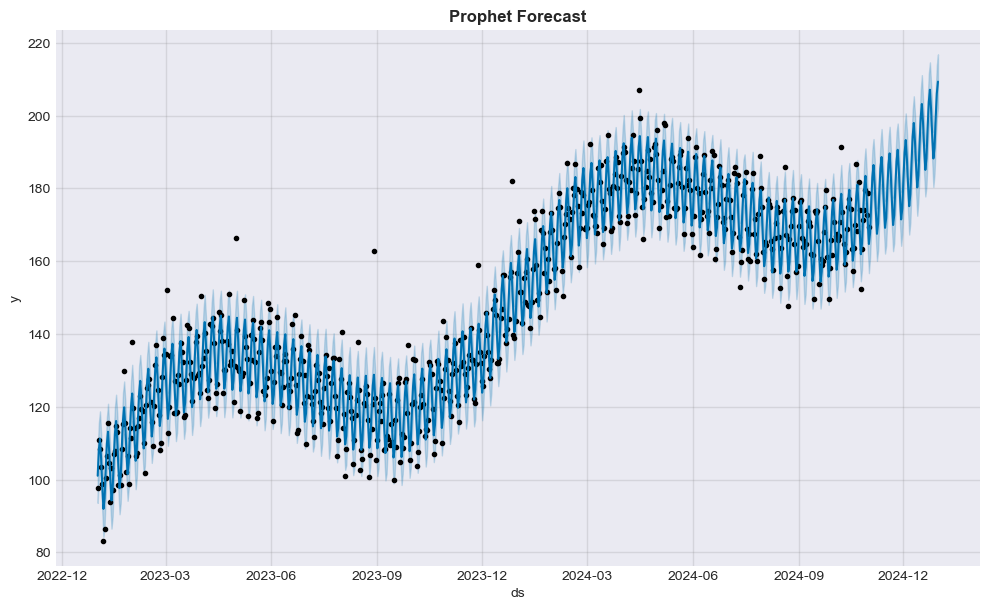

✅ Saved: prophet_forecast.png


In [19]:
# Cell 10: Prophet Model
print("="*70)
print("📊 PROPHET MODEL (Facebook)")
print("="*70)

# Prepare data for Prophet (needs columns 'ds' and 'y')
prophet_train = train[['ds', 'y']].rename(columns={'ds': 'ds', 'y': 'y'})

# Initialize and fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

prophet_model.fit(prophet_train)

# Create future dataframe
future = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future)

# Extract predictions for test period
prophet_predictions = prophet_forecast.iloc[-len(test):]['yhat'].values

# Calculate metrics
prophet_mae = mean_absolute_error(test['y'], prophet_predictions)
prophet_rmse = np.sqrt(mean_squared_error(test['y'], prophet_predictions))
prophet_mape = mean_absolute_percentage_error(test['y'], prophet_predictions)

print(f"\n📊 Prophet Performance:")
print(f"   MAE: {prophet_mae:.2f}")
print(f"   RMSE: {prophet_rmse:.2f}")
print(f"   MAPE: {prophet_mape:.2%}")

# Plot forecast
fig = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast', fontsize=12, fontweight='bold')
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: prophet_forecast.png")

📊 MODEL PERFORMANCE COMPARISON

📊 Model Comparison:
       Model       MAE      RMSE     MAPE
     Prophet  3.952446  4.857638 0.021196
Holt-Winters  7.709988  9.255247 0.040235
       ARIMA 11.718661 14.518562 0.060623


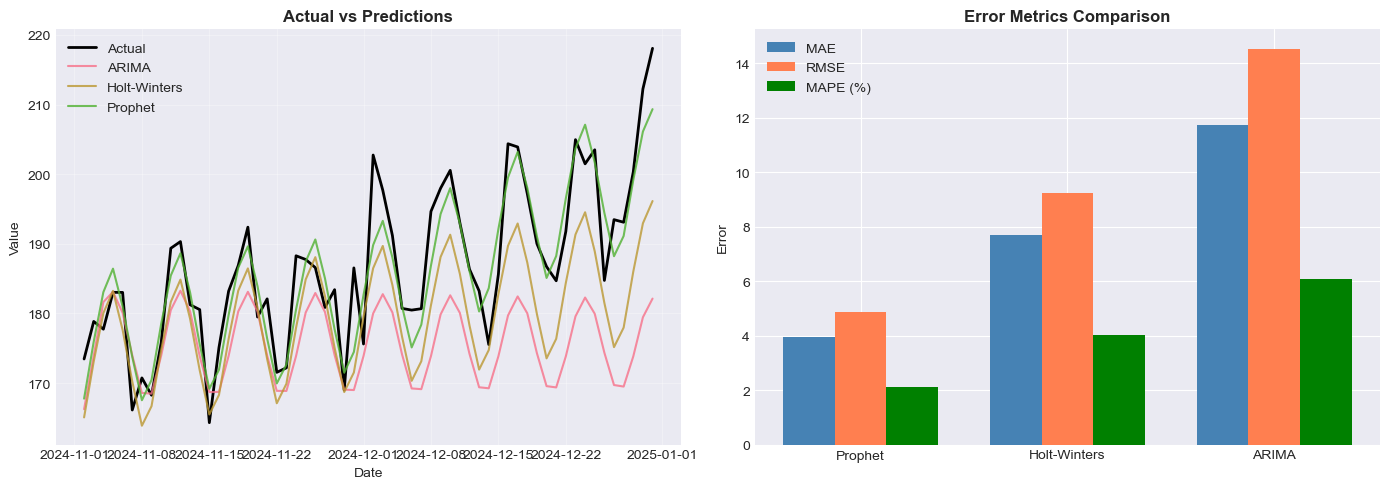

✅ Saved: model_comparison.png

🏆 Best Model: Prophet
   MAPE: 2.12%


In [20]:
# Cell 11: Model Performance Comparison
print("="*70)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Holt-Winters', 'Prophet'],
    'MAE': [arima_mae, hw_mae, prophet_mae],
    'RMSE': [arima_rmse, hw_rmse, prophet_rmse],
    'MAPE': [arima_mape, hw_mape, prophet_mape]
}).sort_values('MAPE')

print("\n📊 Model Comparison:")
print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predictions
ax1 = axes[0]
ax1.plot(test['ds'], test['y'], label='Actual', color='black', linewidth=2)
ax1.plot(test['ds'], arima_predictions, label='ARIMA', alpha=0.8)
ax1.plot(test['ds'], hw_predictions, label='Holt-Winters', alpha=0.8)
ax1.plot(test['ds'], prophet_predictions, label='Prophet', alpha=0.8)
ax1.set_title('Actual vs Predictions', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error Metrics Bar Chart
ax2 = axes[1]
x = np.arange(len(comparison))
width = 0.25
ax2.bar(x - width, comparison['MAE'], width, label='MAE', color='steelblue')
ax2.bar(x, comparison['RMSE'], width, label='RMSE', color='coral')
ax2.bar(x + width, comparison['MAPE'] * 100, width, label='MAPE (%)', color='green')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison['Model'])
ax2.set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Error')
ax2.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

# Best model
best_model = comparison.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model}")
print(f"   MAPE: {comparison.iloc[0]['MAPE']:.2%}")

🔮 FUTURE FORECAST - NEXT 90 DAYS


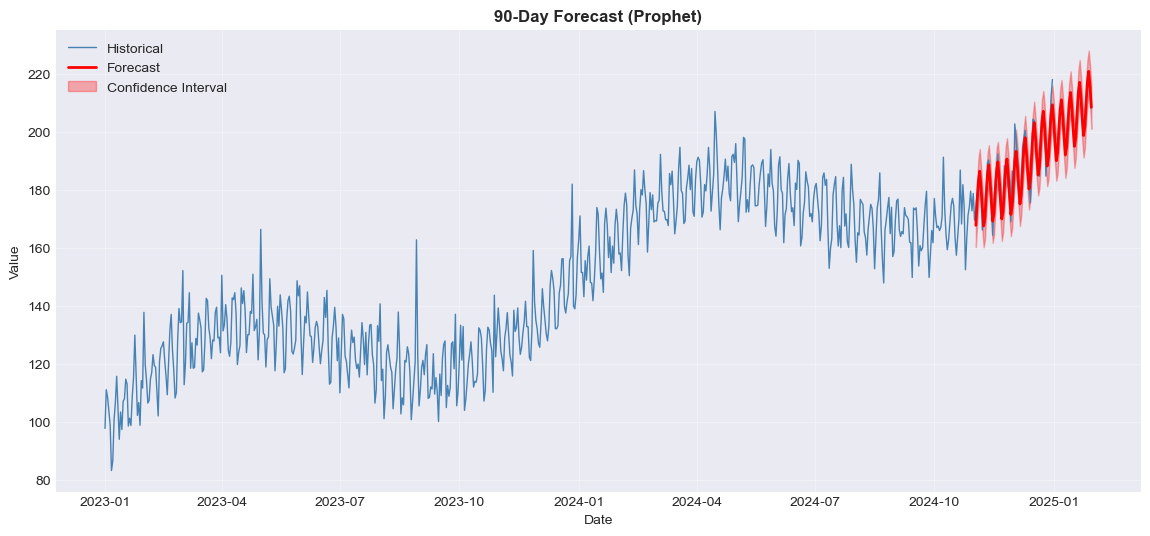

✅ Saved: future_forecast.png


In [21]:
# Cell 12: Future Forecast (Next 90 Days)
print("="*70)
print("🔮 FUTURE FORECAST - NEXT 90 DAYS")
print("="*70)

# Use best model to forecast future
if best_model == 'Prophet':
    future_days = 90
    future = prophet_model.make_future_dataframe(periods=future_days)
    future_forecast = prophet_model.predict(future)
    future_forecast = future_forecast.tail(future_days)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df['ds'], df['y'], label='Historical', color='steelblue', linewidth=1)
    ax.plot(future_forecast['ds'], future_forecast['yhat'], label='Forecast', color='red', linewidth=2)
    ax.fill_between(future_forecast['ds'], 
                     future_forecast['yhat_lower'], 
                     future_forecast['yhat_upper'], 
                     alpha=0.3, color='red', label='Confidence Interval')
    ax.set_title(f'90-Day Forecast ({best_model})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: future_forecast.png")

In [23]:
# Cell 13: Summary Report
print("="*70)
print("🎉 NOTEBOOK 07 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                   TIME SERIES FORECASTING SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📈 DATA OVERVIEW:                                                   ║
║  ├── Daily observations: {len(df)} days                                 ║
║  ├── Train: {len(train)} days | Test: {len(test)} days                    ║
║  └── Value range: {df['y'].min():.2f} - {df['y'].max():.2f}                      ║
║                                                                      ║
║  🤖 MODELS EVALUATED:                                                ║
║  ├── ARIMA - Traditional statistical                                ║
║  ├── Holt-Winters - Exponential smoothing                           ║
║  └── Prophet - Facebook/Meta                                        ║
║                                                                      ║
║  🏆 BEST MODEL: {best_model:<30} ║
║  ├── MAE: {comparison.iloc[0]['MAE']:.2f}                                          ║
║  ├── RMSE: {comparison.iloc[0]['RMSE']:.2f}                                         ║
║  └── MAPE: {comparison.iloc[0]['MAPE']:.2%}                                        ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── time_series_overview.png                                       ║
║  ├── time_series_decomposition.png                                  ║
║  ├── stationarity_test.png                                          ║
║  ├── acf_pacf_plots.png                                             ║
║  ├── train_test_split.png                                           ║
║  ├── prophet_forecast.png                                           ║
║  ├── model_comparison.png                                           ║
║  └── future_forecast.png                                            ║
║                                                                      ║
║  🎯 KEY INSIGHTS:                                                    ║
║  ├── Strong upward trend detected                                   ║
║  ├── Weekly seasonality observed                                    ║
║  ├── Prophet handles changepoints well                              ║
║  └── Forecast uncertainty increases with horizon                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 07 Complete! Ready for Notebook 08 (Anomaly Detection)")

🎉 NOTEBOOK 07 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                   TIME SERIES FORECASTING SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📈 DATA OVERVIEW:                                                   ║
║  ├── Daily observations: 731 days                                 ║
║  ├── Train: 671 days | Test: 60 days                    ║
║  └── Value range: 83.09 - 218.08                      ║
║                                                                      ║
║  🤖 MODELS EVALUATED:                                                ║
║  ├── ARIMA - Traditional statistical                                ║
║  ├── Holt-Winters - Exponential smoothing                           ║
║  └── Prophet - Facebook/Meta                                        ║
║                                               